# Сравнение DES с обыкновенными дифференциальными уравнениями
Методичка предлагает сопоставить индивидуальную стохастическую динамику
с ОДУ. Здесь интенсивность заражения βcSI/(N−1): контакт исключает самого
себя. Это не закон βSI из лабораторной 6. Замыкание среднего поля не
учитывает корреляции S и I, поэтому не обязано совпадать со средним DES.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

In [2]:
rows=NamedTuple[]
grid=collect(0.0:.5:40.0)
curves=Matrix{Float64}(undef,length(grid),20)
for rep in 1:20
    model,result=simulate(family="ode-comparison",seed=7000+rep)
    push!(rows,result)
    curves[:,rep]=sample_step(out(model),grid,:I)
end
save_table("ode-comparison-runs",DataFrame(rows));

## RK4 и контроль шага

In [3]:
coarse=ode_sir(BASE_U,BASE_P,40.0;dt=.02)
fine=ode_sir(BASE_U,BASE_P,40.0;dt=.01)
error=maximum(abs.(Matrix(coarse[:,[:S,:I,:R]])-Matrix(fine[1:2:end,[:S,:I,:R]])))
@assert error < 1e-4
@assert maximum(abs.(fine.S+fine.I+fine.R .- 1000)) < 1e-8
save_table("ode-trajectory",fine)
save_table("ode-convergence",DataFrame(dt=[.02],reference_dt=[.01],max_difference=[error]))
display((dt=.02,reference_dt=.01,max_difference=error))

(dt = 0.02, reference_dt = 0.01, max_difference = 1.0888925316976383e-9)

## Ансамбль и разброс

In [4]:
avg=vec(mean(curves;dims=2))
sd=vec(std(curves;dims=2))
lo=[quantile(curves[j,:],.1) for j in axes(curves,1)]
hi=[quantile(curves[j,:],.9) for j in axes(curves,1)]
ensemble=save_table("ode-ensemble",DataFrame(t=grid,mean_I=avg,sd_I=sd,q10=lo,q90=hi))
display(first(ensemble,8))

Row,t,mean_I,sd_I,q10,q90
,Float64,Float64,Float64,Float64,Float64
1,0.0,10.0,0.0,10.0,10.0
2,0.5,11.45,1.57196,9.9,13.1
3,1.0,12.55,3.17017,9.0,16.0
4,1.5,14.0,4.26738,9.9,17.3
5,2.0,15.1,5.23048,10.0,20.0
6,2.5,16.35,6.64336,9.9,25.1
7,3.0,18.4,8.65357,10.0,28.9
8,3.5,19.85,9.82625,9.8,33.6


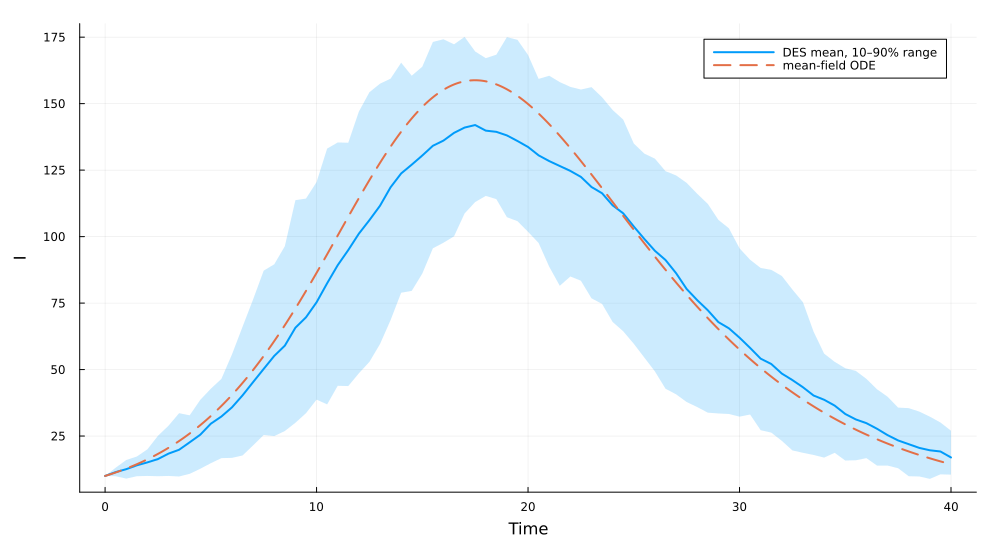

In [5]:
fig=plot(grid,avg;ribbon=(avg-lo,hi-avg),fillalpha=.2,label="DES mean, 10–90% range",
    xlabel="Time",ylabel="I",lw=2,size=(1000,550))
plot!(fig,fine.t,fine.I;label="mean-field ODE",lw=2,linestyle=:dash)
savefig(fig,figure_path("14-plot"))
display(fig)

Полоса показывает межтраекторные квантили, а не доверительный интервал
среднего. Двадцать повторов недостаточны для точной оценки редких событий.

In [6]:
k=argmax(fine.I)
result=DataFrame(ode_peak=[fine.I[k]],ode_peak_time=[fine.t[k]],
    des_mean_of_peaks=[mean(getproperty.(rows,:peak_I))],
    des_peak_of_mean=[maximum(avg)])
save_table("ode-comparison-summary",result)
display(result)

Row,ode_peak,ode_peak_time,des_mean_of_peaks,des_peak_of_mean
,Float64,Float64,Float64,Float64
1,158.793,17.49,160.4,141.95
